# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

## Loan Approval Analysis

In this lab, I compared **age, sex, and five additional features** with `loan_status` to see which variables appear most related to whether a loan is approved.

The five extra features I selected were:

1. `person_income`
2. `loan_percent_income`
3. `credit_score`
4. `person_home_ownership`
5. `previous_loan_defaults_on_file`

I used **boxplots** for quantitative features and **bar charts of approval rate** for categorical features so the comparisons stay quantitative and match the lab instructions.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


## Quick Summary Statistics

In [7]:
approval_rate = df.groupby("loan_status").size() / len(df)

age_summary = df.groupby("loan_status")["person_age"].agg(["mean", "median"])
income_summary = df.groupby("loan_status")["person_income"].agg(["mean", "median"])
loan_pct_summary = df.groupby("loan_status")["loan_percent_income"].agg(["mean", "median"])
credit_summary = df.groupby("loan_status")["credit_score"].agg(["mean", "median"])

print("Overall approval rate:")
display(approval_rate.rename({0: "Rejected", 1: "Approved"}))

print("\nAge summary by loan status:")
display(age_summary)

print("\nIncome summary by loan status:")
display(income_summary)

print("\nLoan percent income summary by loan status:")
display(loan_pct_summary)

print("\nCredit score summary by loan status:")
display(credit_summary)

Overall approval rate:


loan_status
Rejected    0.891267
Approved    0.108733
dtype: float64


Age summary by loan status:


,mean,median
loan_status,,
0,54.021318,55.0
1,39.482117,39.0



Income summary by loan status:


,mean,median
loan_status,,
0,58528.531356,58519.753892
1,73514.758800,74654.580855



Loan percent income summary by loan status:


,mean,median
loan_status,,
0,0.305799,0.263221
1,0.184616,0.181438



Credit score summary by loan status:


,mean,median
loan_status,,
0,676.202446,675.642685
1,709.749597,717.207593


From the summary tables, approved applicants are generally:

- **younger**
- **higher income**
- **asking for a smaller loan relative to income**
- **higher credit score**

Those patterns suggest these variables may matter more than sex, but the visualizations below make the relationships easier to compare.

## 1. Age vs. Loan Status

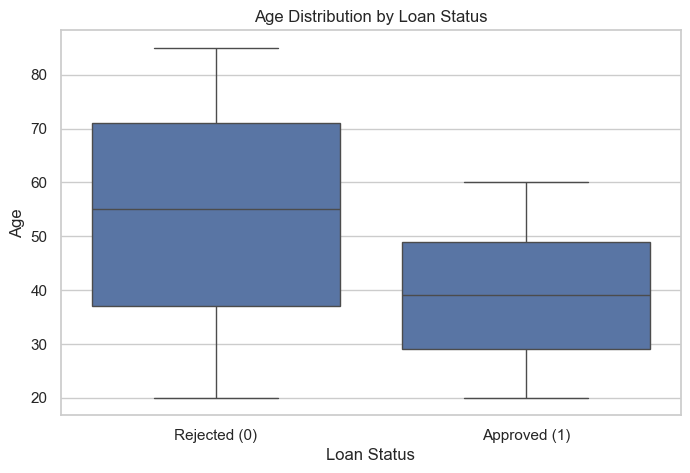

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="loan_status", y="person_age")
plt.xticks([0, 1], ["Rejected (0)", "Approved (1)"])
plt.title("Age Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Age")
plt.show()

The boxplot shows a **clear age difference**. The approved group is centered at a noticeably younger age than the rejected group.  
This suggests **age is related to the model's decision**, which could raise fairness concerns because age was one of the features customers complained about.

## 2. Gender vs. Loan Status

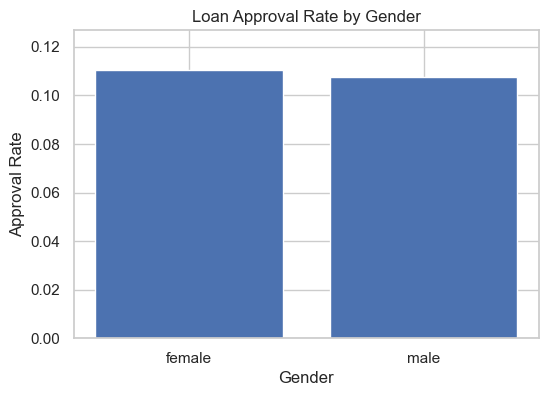

person_gender
female    0.110280
male      0.107711
Name: 1, dtype: float64

In [9]:
gender_rates = pd.crosstab(df["person_gender"], df["loan_status"], normalize="index")[1].sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(gender_rates.index, gender_rates.values)
plt.title("Loan Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0, max(gender_rates.values) * 1.15)
plt.show()

gender_rates

The approval rates for male and female applicants are **almost identical**.  
This makes **gender one of the least related features** in this analysis. Based on this visualization alone, sex does **not** appear to be driving the model strongly.

## 3. Income vs. Loan Status

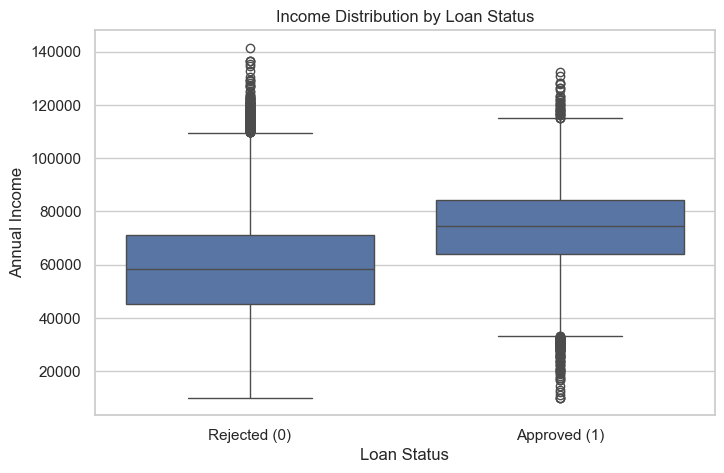

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="loan_status", y="person_income")
plt.xticks([0, 1], ["Rejected (0)", "Approved (1)"])
plt.title("Income Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
plt.show()

The approved group has a **higher income distribution overall** than the rejected group.  
This suggests `person_income` is **meaningfully related** to approval, which makes sense because income affects a person's ability to repay a loan.

## 4. Loan Percent of Income vs. Loan Status

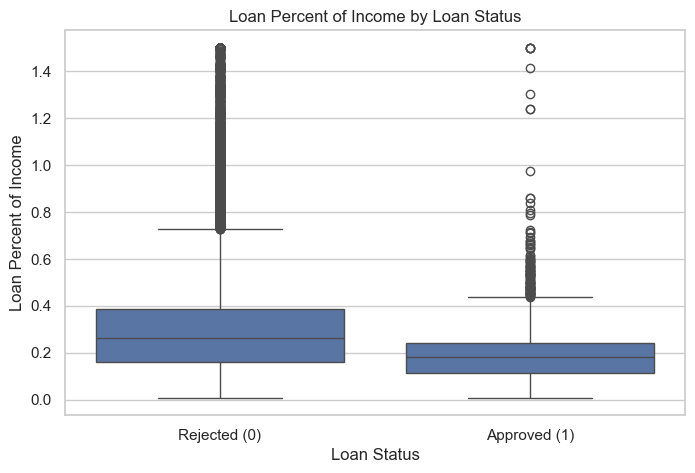

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="loan_status", y="loan_percent_income")
plt.xticks([0, 1], ["Rejected (0)", "Approved (1)"])
plt.title("Loan Percent of Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Percent of Income")
plt.show()

This is one of the **strongest relationships** in the notebook. Approved applicants tend to request loans that make up a **smaller share of their income**, while rejected applicants have much higher values.

That means `loan_percent_income` appears to be a **major driver** of the decision.

## 5. Credit Score vs. Loan Status

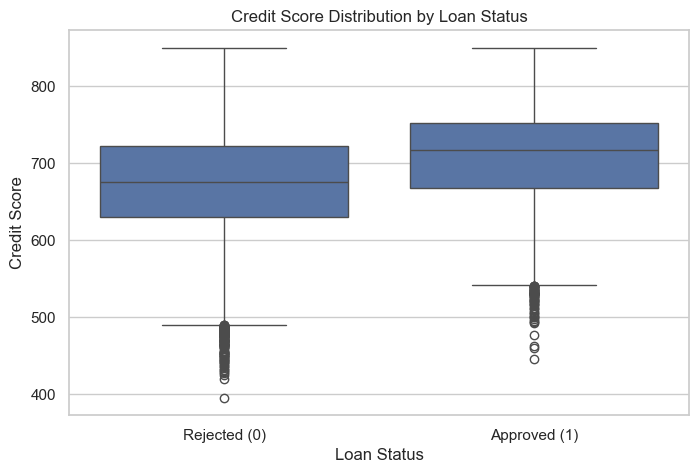

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="loan_status", y="credit_score")
plt.xticks([0, 1], ["Rejected (0)", "Approved (1)"])
plt.title("Credit Score Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")
plt.show()

The approved group has a **higher median credit score** and the boxplot is shifted upward compared with the rejected group.

This makes `credit_score` another feature that seems **strongly related** to approval.

## 6. Home Ownership vs. Loan Status

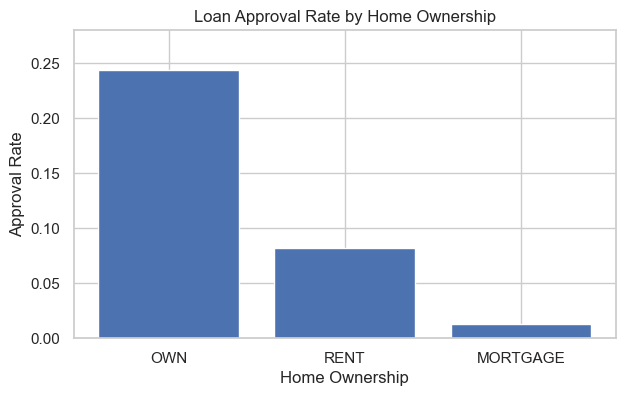

person_home_ownership
OWN         0.243471
RENT        0.082253
MORTGAGE    0.013035
Name: 1, dtype: float64

In [13]:
home_rates = pd.crosstab(df["person_home_ownership"], df["loan_status"], normalize="index")[1].sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(home_rates.index, home_rates.values)
plt.title("Loan Approval Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Approval Rate")
plt.ylim(0, max(home_rates.values) * 1.15)
plt.show()

home_rates

Home ownership status also looks related to approval. In this dataset, applicants listed as **OWN** have the highest approval rate, while **MORTGAGE** has the lowest.

So `person_home_ownership` does **not** look unrelated; it appears to influence the model's outcome.

## 7. Previous Loan Defaults vs. Loan Status

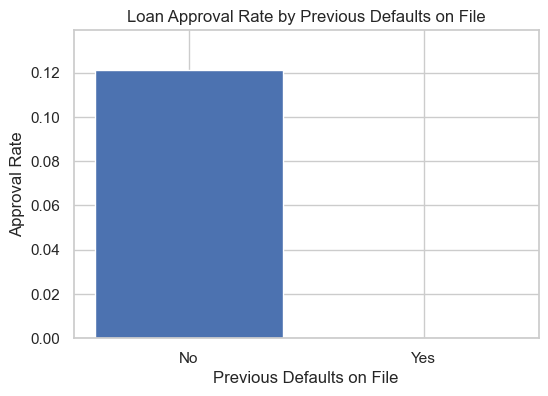

previous_loan_defaults_on_file
No     0.120967
Yes    0.000000
Name: 1, dtype: float64

In [14]:
default_rates = pd.crosstab(df["previous_loan_defaults_on_file"], df["loan_status"], normalize="index")[1].sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(default_rates.index, default_rates.values)
plt.title("Loan Approval Rate by Previous Defaults on File")
plt.xlabel("Previous Defaults on File")
plt.ylabel("Approval Rate")
upper = max(default_rates.values) * 1.15 if max(default_rates.values) > 0 else 0.1
plt.ylim(0, upper)
plt.show()

default_rates

This feature appears **extremely related** to the decision. Applicants with a previous default on file have an approval rate near **zero**, while applicants without a previous default are approved much more often.

That makes `previous_loan_defaults_on_file` one of the **strongest drivers** in the model.

## Final Conclusion

Based on these visualizations, the features that seem **most related** to loan approval are:

- `previous_loan_defaults_on_file`
- `loan_percent_income`
- `credit_score`
- `person_income`
- `person_home_ownership`

Of the protected features mentioned in the complaint:

- **Gender** looks **mostly unrelated** to the model's decision because the approval rates are nearly the same across groups.
- **Age** looks **more related** to the decision because approved applicants are clearly younger than rejected applicants in the boxplot.

### Should the financial institution be concerned?

Yes, the institution should be **somewhat concerned**, especially about **age**. Even though several financial variables appear to be stronger drivers than age, the age visualization still shows a noticeable difference between approved and rejected applicants. That means age may be influencing the model directly or may be acting as a proxy for other factors.

At the same time, the visualizations do provide evidence that the model is also relying heavily on reasonable financial variables such as **credit score**, **loan burden relative to income**, **income**, and **prior default history**. So the strongest concern from this notebook is **age**, not **sex**.